In [ ]:
#BirdClef Dataset

In [ ]:
import pandas as pd 
import os 
from src.util.stats import get_audio_folder_stats, get_label_distribution_count, fuse_soundscapes_rows_per_file, get_perch_labels
from src.util.visualization import plot_audio_stats, plot_family_distribution, plot_label_distribution_count, plot_count_stats, plot_date_distribution, plot_time_distribution

In [72]:
#change current data directory to the root of the project
os.chdir("/root/birdclef-ml-framework/")

In [73]:
taxonomy_df = pd.read_csv("./data/birdclef_dataset/taxonomy.csv")
sample_submission_df = pd.read_csv("./data/birdclef_dataset/sample_submission.csv")
train_soundscapes_labels_df = pd.read_csv("./data/birdclef_dataset/train_soundscapes_labels.csv")
train_df = pd.read_csv("./data/birdclef_dataset/train.csv")

train_audio_path = "./data/birdclef_dataset/train_audio/"
train_soundscapes_path = "./data/birdclef_dataset/train_soundscapes/"

## Audio Stats

Skipping Audio file XC862355.ogg has length 900.144 seconds
Skipping Audio file XC1038665.ogg has length 3889.057 seconds
Skipping Audio file iNat1166565.ogg has length 744.024 seconds
Skipping Audio file iNat1166832.ogg has length 636.024 seconds
Skipping Audio file iNat1166568.ogg has length 876.024 seconds
Skipping Audio file iNat1166662.ogg has length 696.024 seconds
Skipping Audio file XC833295.ogg has length 1215.96996875 seconds
Skipping Audio file iNat1166566.ogg has length 756.024 seconds
Skipping Audio file iNat1166747.ogg has length 870.024 seconds
Skipping Audio file XC705946.ogg has length 663.384 seconds
Skipping Audio file iNat1600436.ogg has length 734.0146875 seconds
Skipping Audio file XC936081.ogg has length 946.128 seconds
Skipping Audio file XC879442.ogg has length 1076.904 seconds
Skipping Audio file XC924010.ogg has length 933.6946875 seconds
Skipping Audio file XC864073.ogg has length 1654.20409375 seconds
Skipping Audio file XC1047952.ogg has length 3032.241 se

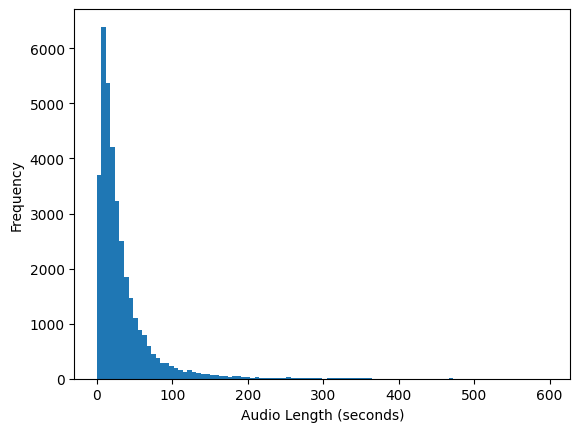

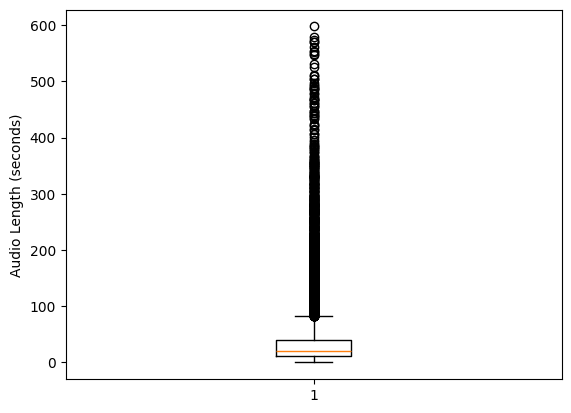

In [75]:
num_files, audio_lengths = get_audio_folder_stats(train_audio_path)
plot_audio_stats(num_files, audio_lengths, train_audio_path)

[21.2114375, 9.40371875, 19.7750625, 27.6114375, 9.852625, 26.644, 25.36490625, 43.71353125, 12.65278125, 25.05434375]
Number of audio files smaller than 5 seconds: 2601
Number of audio files in ./data/birdclef_dataset/train_audio/: 2601
Average audio length in seconds: 3.27


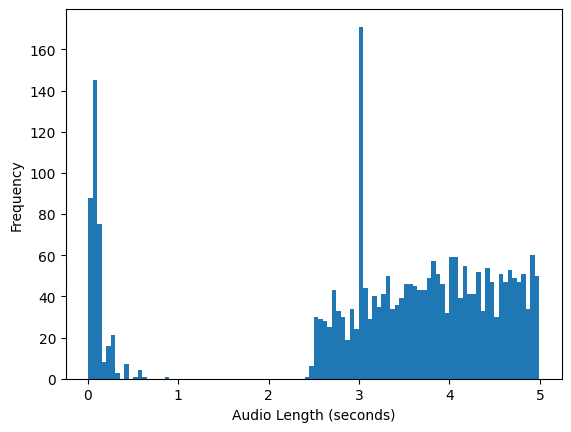

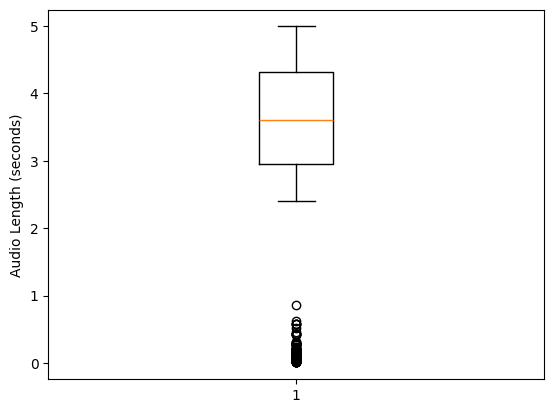

In [76]:
print(audio_lengths[:10])
smaller_than_five_seconds = [length for length in audio_lengths if length < 5]
print("Number of audio files smaller than 5 seconds: {}".format(len(smaller_than_five_seconds)))
plot_audio_stats(len(smaller_than_five_seconds), smaller_than_five_seconds, train_audio_path)

Max length audio file BC2026_Train_6840_S13_20231226_020000.ogg with length 60.0 seconds
Number of audio files in ./data/birdclef_dataset/train_soundscapes/: 10658
Average audio length in seconds: 60.00


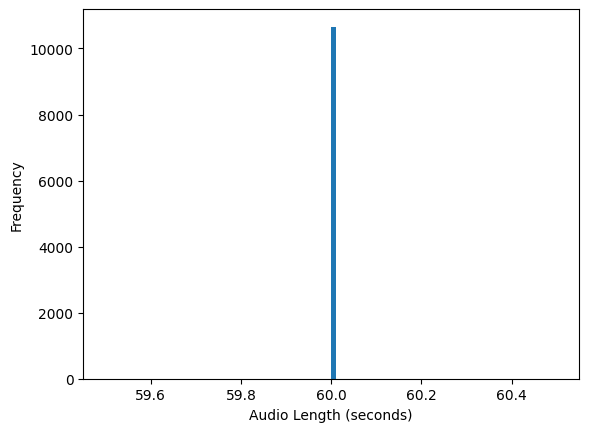

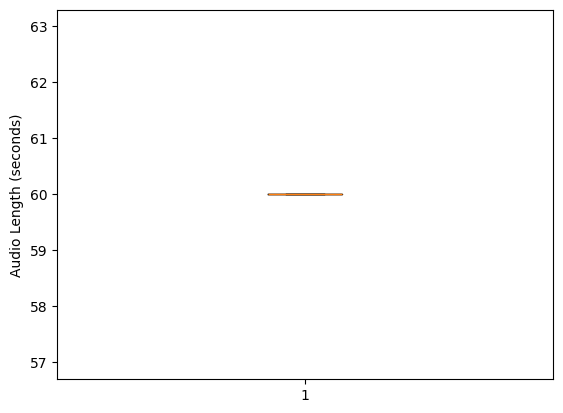

In [77]:
num_files, audio_lengths = get_audio_folder_stats(train_soundscapes_path)
plot_audio_stats(num_files, audio_lengths, train_soundscapes_path)

## DF stats

### Sample Submission

In [78]:
# sample submission 
print("Sample submission row : filename, list of probs for every class")
print(sample_submission_df.head(1))

Sample submission row : filename, list of probs for every class
                                   row_id   1161364    116570   1176823  \
0  BC2026_Test_0001_S05_20250227_010002_5  0.004274  0.004274  0.004274   

    1491113   1595929    209233     22930     22956     22961  ...   whnjay1  \
0  0.004274  0.004274  0.004274  0.004274  0.004274  0.004274  ...  0.004274   

     whtdov   whwpic1    y00678    yebcar   yebela1    yecmac    yecpar  \
0  0.004274  0.004274  0.004274  0.004274  0.004274  0.004274  0.004274   

    yehcar1   yeofly1  
0  0.004274  0.004274  

[1 rows x 235 columns]


### Taxonomy

  primary_label  inat_taxon_id scientific_name   common_name class_name
0       1161364        1161364    Guyalna cuta  Guyalna cuta    Insecta
Number of unique species in taxonomy: 234
Number of unique taxon ids in taxonomy: 210
Number of unique scientific names in taxonomy: 234
Number of unique common names in taxonomy: 234
Number of unique classes in taxonomy: 5


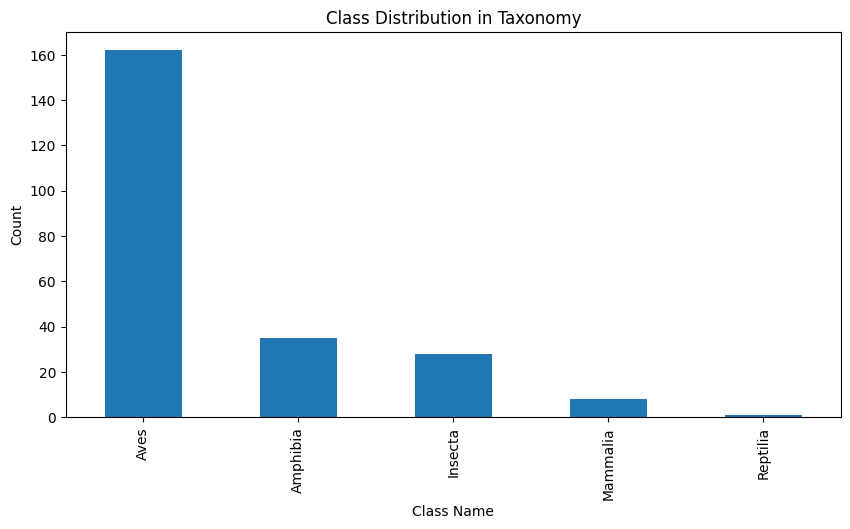

Class names in taxonomy: ['Insecta' 'Reptilia' 'Amphibia' 'Mammalia' 'Aves']
Number of classes in taxonomy: class_name
Aves        162
Amphibia     35
Insecta      28
Mammalia      8
Reptilia      1
Name: count, dtype: int64


In [ ]:
# taxonomy 
print(taxonomy_df.head(1))

#columns primary_label,inat_taxon_id,scientific_name,common_name,class_name
print("Number of unique species in taxonomy: {}".format(taxonomy_df["primary_label"].nunique()))
print("Number of unique taxon ids in taxonomy: {}".format(taxonomy_df["inat_taxon_id"].nunique()))
print("Number of unique scientific names in taxonomy: {}".format(taxonomy_df["scientific_name"].nunique()))
print("Number of unique common names in taxonomy: {}".format(taxonomy_df["common_name"].nunique()))
print("Number of unique classes in taxonomy: {}".format(taxonomy_df["class_name"].nunique()))

plot_family_distribution(taxonomy_df)
print("Class names in taxonomy: {}".format(taxonomy_df["class_name"].unique()))
print("Number of classes in taxonomy: {}".format(taxonomy_df["class_name"].value_counts()))

### Train DF 

  primary_label secondary_labels type  latitude  longitude scientific_name  \
0       1161364               []   []  -22.7562   -46.8666    Guyalna cuta   

    common_name class_name  inat_taxon_id         author   license  rating  \
0  Guyalna cuta    Insecta        1161364  Lucas Barbosa  cc-by-nc     0.0   

                                                 url                 filename  \
0  https://static.inaturalist.org/sounds/1216197....  1161364/iNat1216197.ogg   

  collection  
0       iNat  
Min Longitude: -159.6556
Max Longitude: 175.3239
Min Latitude: -54.8574
Max Latitude: 69.578
Number of animals labeled in train soundscapes labels: 206


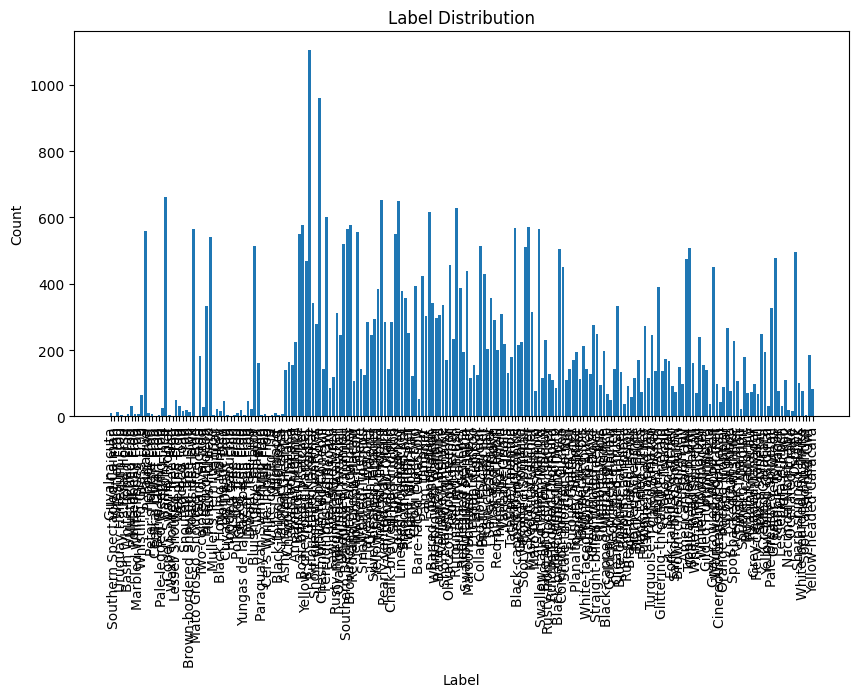

In [ ]:
print(train_df.head(1))

print("Min Longitude: {}".format(train_df["longitude"].min()))
print("Max Longitude: {}".format(train_df["longitude"].max()))
print("Min Latitude: {}".format(train_df["latitude"].min()))
print("Max Latitude: {}".format(train_df["latitude"].max()))

train_df_labels_count = get_label_distribution_count(train_df, taxonomy_df)
plot_label_distribution_count(train_df_labels_count)

## Train_SoundScapesDF

Index(['filename', 'start', 'end', 'primary_label'], dtype='object')
Length of train soundscapes labels: 1478
Number of unique filenames in train soundscapes labels: 66
Train soundscapes with labels: 66
Train soundscapes without labels: 1412


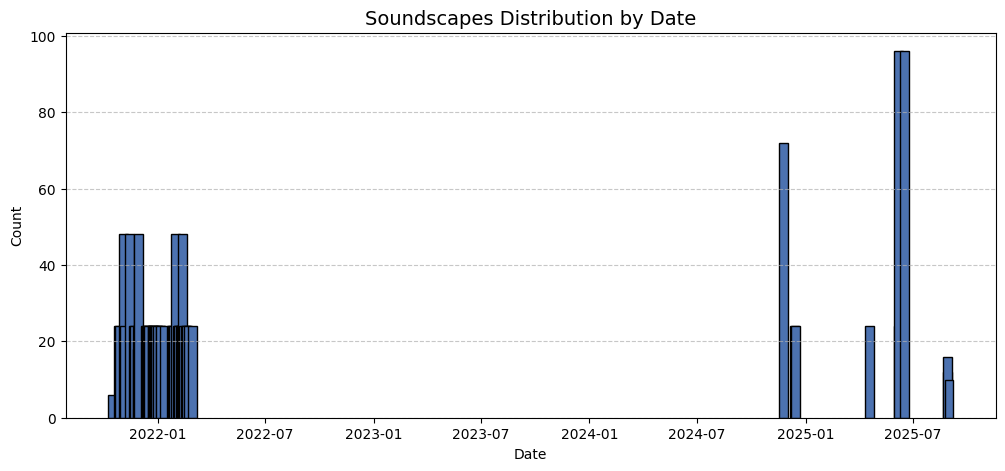

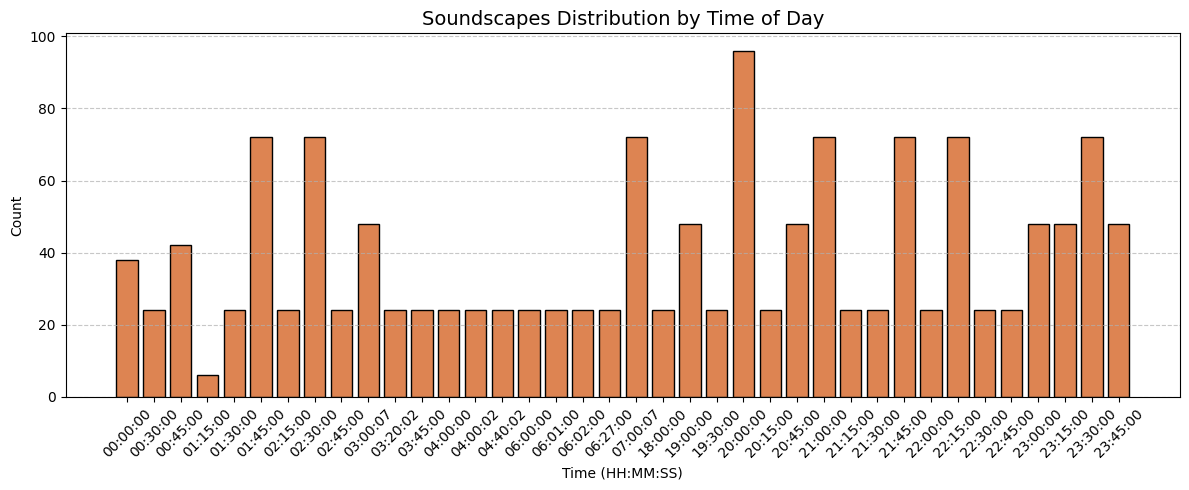

Date distribution in train soundscapes labels:
Time distribution in train soundscapes labels:
Number of animals labeled in train soundscapes labels: 75
Number of animals labeled in train soundscapes labels: 75


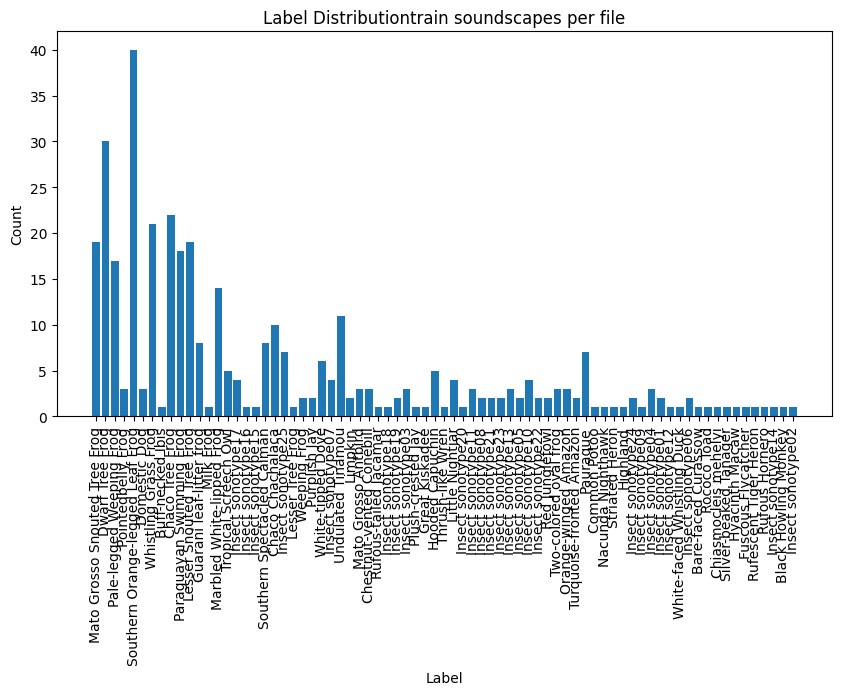

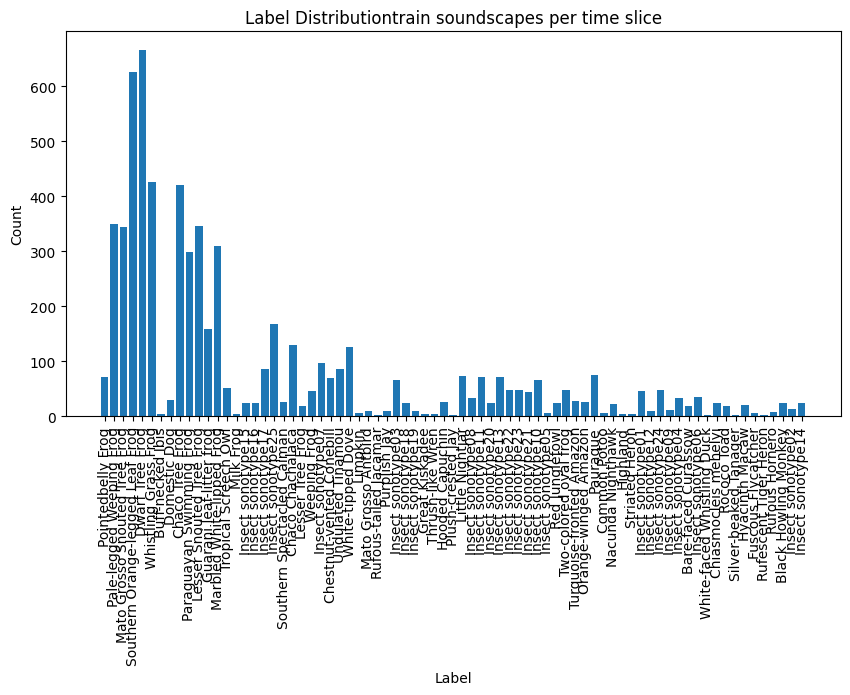

In [ ]:
#print(train_soundscapes_labels_df.head(1))
print(train_soundscapes_labels_df.columns)

print("Length of train soundscapes labels: {}".format(len(train_soundscapes_labels_df)))
print("Number of unique filenames in train soundscapes labels: {}".format(train_soundscapes_labels_df["filename"].nunique()))

#train_soundscapes 
train_soundscapes_with_labels = train_soundscapes_labels_df["filename"].nunique()
train_soundscapes_without_labels = len(train_soundscapes_labels_df) - train_soundscapes_with_labels
print("Train soundscapes with labels: {}".format(train_soundscapes_with_labels))
print("Train soundscapes without labels: {}".format(train_soundscapes_without_labels))

#time distribution 
plot_date_distribution(train_soundscapes_labels_df)
plot_time_distribution(train_soundscapes_labels_df)


print("Date distribution in train soundscapes labels:")
date_distribution = train_soundscapes_labels_df["date"].value_counts()
print("Time distribution in train soundscapes labels:")
time_distribution = train_soundscapes_labels_df["time"].value_counts()

#get label distribution 
train_soundscapes_labels_df_file_fused = fuse_soundscapes_rows_per_file(train_soundscapes_labels_df)
train_soundscapes_labels_df_count = get_label_distribution_count(train_soundscapes_labels_df_file_fused, taxonomy_df)
plot_label_distribution_count(train_soundscapes_labels_df_count, title="train soundscapes per file")
plot_label_distribution_count(get_label_distribution_count(train_soundscapes_labels_df, taxonomy_df), title="train soundscapes per time slice")



Number of animals labeled in train soundscapes labels: 234
                 0
count   234.000000
mean    185.256410
std     198.142865
min       1.000000
25%      20.250000
50%     123.000000
75%     285.500000
max    1107.000000


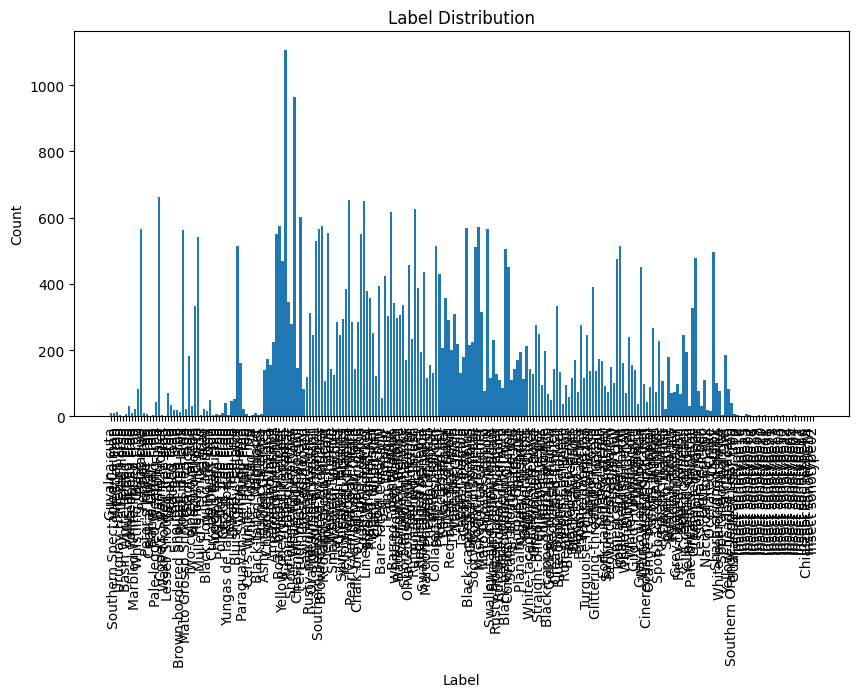

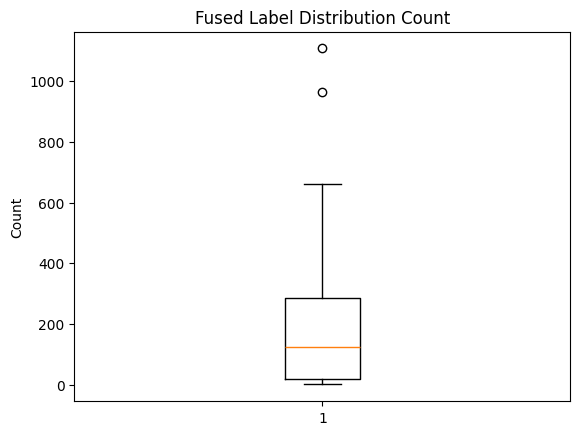

In [86]:
#fuse counts from train_df_labels_count and train_soundscapes_labels_df_count
fused_labels_count = train_df_labels_count.copy()
for label, count in train_soundscapes_labels_df_count.items():
    if label in fused_labels_count:
        fused_labels_count[label] += count
    else:
        fused_labels_count[label] = count

plot_label_distribution_count(fused_labels_count)

plot_count_stats(fused_labels_count, "Fused Label Distribution Count")



In [87]:
print("class_mapping:", fused_labels_count)

class_mapping: {'Guyalna cuta': 11, 'Southern Spectacled Caiman': 9, 'Wrestler Frog': 12, 'Uruguay Harlequin Frog': 5, 'Feral Horse': 2, 'Basin White-lipped Frog': 6, 'Mustached Frog': 32, 'Pointedbelly Frog': 9, 'Marbled White-lipped Frog': 22, 'Whistling Grass Frog': 84, 'Pauraque': 565, 'Pepper Frog': 10, "Peter's Jungle Frog": 6, 'Central Dwarf Frog': 1, 'Bahia Dwarf Frog': 5, 'Pale-legged Weeping Frog': 43, 'Saffron Finch': 662, "Cope's Swamp Froglet": 4, 'Waxy Monkey Tree Frog': 1, 'Lesser Snouted Tree Frog': 69, 'Weeping Frog': 33, 'Rococo Toad': 18, 'Snouted Tree Frog': 19, 'Brown-bordered Snouted Tree Frog': 12, 'Roadside Hawk': 564, 'Mato Grosso Snouted Tree Frog': 21, 'Giant Cicada': 181, 'Two-colored oval frog': 32, 'Picazuro Pigeon': 334, 'Rufous Hornero': 541, "Muller's Termite Frog": 3, 'Jaguar': 22, 'Black Howling Monkey': 16, 'Domestic Dog': 48, 'Cuyaba Dwarf Frog': 3, 'Hooded Capuchin': 6, 'Usina Tree Frog': 3, 'Polka-dot Tree Frog': 9, 'Chaco Tree Frog': 40, 'Yungas 

In [ ]:
#get number of species encoded by perch model of goole 

perch_labels = get_perch_labels()
taxonomy_df["scientific_name"] = taxonomy_df["scientific_name"].str.lower()
taxonomy_labels = taxonomy_df["scientific_name"].tolist()

#find intersection of perch labels and taxonomy labels
intersection_labels = set(perch_labels).intersection(set(taxonomy_labels))
print("Number of species in Perch model that are also in taxonomy:", len(intersection_labels))

#find species in taxonomy that are not in perch model
taxonomy_labels_not_in_perch = set(taxonomy_labels) - set(perch_labels)
print("Number of species in taxonomy that are not in Perch model:", len(taxonomy_labels_not_in_perch))
print(taxonomy_labels_not_in_perch)

Number of species in Perch model: 14795
First 5 rows of Perch model class mapping:
            inat2024_fsd50k
0        Abavorana luctuosa
1         Abeillia abeillei
2    Abroscopus albogularis
3    Abroscopus schisticeps
4  Abroscopus superciliaris
Number of species in Perch model that are also in taxonomy: 203
Number of species in taxonomy that are not in Perch model: 31
{'insect son24', 'insect son17', 'insect son14', 'insect son05', 'insect son02', 'insect son09', 'insect son13', 'insect son16', 'insect son11', 'insect son25', 'insect son12', 'insect son07', 'sapajus cay', 'insect son10', 'insect son20', 'insect son15', 'insect son06', 'lysapsus limellum', 'insect son04', 'insect son18', 'insect son01', 'insect son21', 'insect son22', 'insect son03', 'insect son08', 'mico melanurus', 'insect son23', 'chiasmocleis mehelyi', 'insect son19', 'adenomera guarani', 'caiman yacare'}


Counts of species in taxonomy that are not in Perch model:
Black-tailed Marmoset: 3
Chiasmocleis mehelyi: 1
Guaraní leaf-litter frog: 8
Hooded Capuchin: 6
Insect sonotype01: 2
Insect sonotype02: 1
Insect sonotype03: 3
Insect sonotype04: 3
Insect sonotype05: 2
Insect sonotype06: 2
Insect sonotype07: 4
Insect sonotype08: 2
Insect sonotype09: 1
Insect sonotype10: 4
Insect sonotype11: 3
Insect sonotype12: 1
Insect sonotype13: 3
Insect sonotype14: 1
Insect sonotype15: 1
Insect sonotype16: 1
Insect sonotype17: 4
Insect sonotype18: 1
Insect sonotype19: 2
Insect sonotype20: 1
Insect sonotype21: 2
Insect sonotype22: 2
Insect sonotype23: 2
Insect sonotype24: 2
Insect sonotype25: 7
Southern Spectacled Caiman: 9
Uruguay Harlequin Frog: 5
Number of animals labeled in train soundscapes labels: 31
Counts of species in taxonomy that are not in Perch model without sonotypes:
Black-tailed Marmoset: 3
Chiasmocleis mehelyi: 1
Guaraní leaf-litter frog: 8
Hooded Capuchin: 6
Southern Spectacled Caiman: 9
Uru

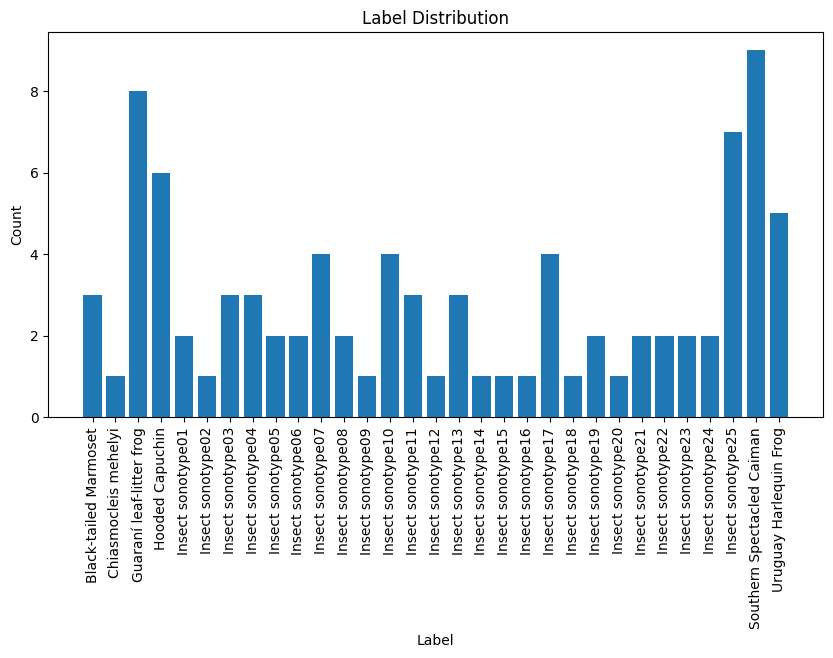

In [89]:
#counts of species in taxonomy that are not in perch model
taxonomy_labels_not_in_perch_count = {}
#real names 
real_names = sorted([taxonomy_df[taxonomy_df["scientific_name"] == label]["common_name"].values[0] for label in taxonomy_labels_not_in_perch])
for real_name in real_names:
    taxonomy_labels_not_in_perch_count[real_name] = fused_labels_count.get(real_name, 0)

print("Counts of species in taxonomy that are not in Perch model:")
for label, count in taxonomy_labels_not_in_perch_count.items():
    print(f"{label}: {count}")
plot_label_distribution_count(taxonomy_labels_not_in_perch_count)

print("Counts of species in taxonomy that are not in Perch model without sonotypes:")
#print without sonotypes
for label, count in taxonomy_labels_not_in_perch_count.items():
    if "sonotype" not in label.lower():
        print(f"{label}: {count}")

In [90]:
#species with less than 3 files in the dataset
print("Species with less than 3 files in the dataset:")
for label, count in fused_labels_count.items():
    if count < 3:
        print(f"{label}: {count}")

Species with less than 3 files in the dataset:
Feral Horse: 2
Central Dwarf Frog: 1
Waxy Monkey Tree Frog: 1
Cei's White-lipped Frog: 2
Insect sonotype16: 1
Insect sonotype15: 1
Insect sonotype18: 1
Insect sonotype19: 2
Insect sonotype20: 1
Insect sonotype08: 2
Insect sonotype21: 2
Insect sonotype23: 2
Insect sonotype05: 2
Insect sonotype22: 2
Insect sonotype24: 2
Insect sonotype09: 1
Insect sonotype01: 2
Insect sonotype12: 1
Insect sonotype06: 2
Chiasmocleis mehelyi: 1
Insect sonotype14: 1
Insect sonotype02: 1


In [ ]:
#species below 52 (25% quantile of fused label distribution count)
#species with less than 3 files in the dataset
print("Species with less than 52 files in the dataset:")
for label, count in sorted(fused_labels_count.items(), key=lambda x: x[0]):
    label_scientific_name = taxonomy_df[taxonomy_df["common_name"] == label]["scientific_name"].values[0].lower()
    is_in_perch = label_scientific_name in perch_labels
    is_in_soundscapes = label in train_soundscapes_labels_df_count.keys()
    is_in_train_audio = label in train_df_labels_count.keys()
    if count < 52 and not is_in_perch:
        print(f"{label}: {count} (In Perch: {is_in_perch}, In Soundscapes: {is_in_soundscapes}, In Train Audio: {is_in_train_audio})")
        print(f"File name: ")

Species with less than 52 files in the dataset:
Black-tailed Marmoset: 3 (In Perch: False, In Soundscapes: False, In Train Audio: True)
Chiasmocleis mehelyi: 1 (In Perch: False, In Soundscapes: True, In Train Audio: False)
Guaraní leaf-litter frog: 8 (In Perch: False, In Soundscapes: True, In Train Audio: False)
Hooded Capuchin: 6 (In Perch: False, In Soundscapes: True, In Train Audio: True)
Insect sonotype01: 2 (In Perch: False, In Soundscapes: True, In Train Audio: False)
Insect sonotype02: 1 (In Perch: False, In Soundscapes: True, In Train Audio: False)
Insect sonotype03: 3 (In Perch: False, In Soundscapes: True, In Train Audio: False)
Insect sonotype04: 3 (In Perch: False, In Soundscapes: True, In Train Audio: False)
Insect sonotype05: 2 (In Perch: False, In Soundscapes: True, In Train Audio: False)
Insect sonotype06: 2 (In Perch: False, In Soundscapes: True, In Train Audio: False)
Insect sonotype07: 4 (In Perch: False, In Soundscapes: True, In Train Audio: False)
Insect sonotype08